In [1]:
# Install if needed
!pip install pandas scikit-learn nltk matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load CSV
df = pd.read_csv("Geyser.csv")

# Preview
df.head()

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 7.7 KB


,duration,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


In [7]:
print(df.columns)

Index(['duration', 'waiting', 'kind'], dtype='str')


In [10]:
print(df.columns.tolist())

['duration', 'waiting', 'kind']


In [13]:
from sklearn.cluster import KMeans

# Use all numeric columns
X = df.select_dtypes(include=["number"])

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

df["cluster"] = kmeans.labels_

df.head()

,duration,waiting,kind,cluster
0,3.600,79,long,2
1,1.800,54,short,1
2,3.333,74,long,2
3,2.283,62,short,1
4,4.533,85,long,0


In [16]:
# 1. Inspect columns
print(df.columns)



Index(['duration', 'waiting', 'kind', 'cluster'], dtype='str')


In [17]:
df.head()

,duration,waiting,kind,cluster
0,3.600,79,long,2
1,1.800,54,short,1
2,3.333,74,long,2
3,2.283,62,short,1
4,4.533,85,long,0


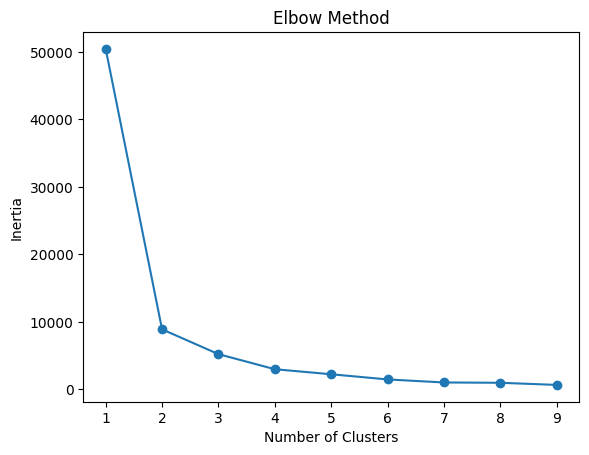

In [18]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [20]:
print(df.dtypes)

duration    float64
waiting       int64
kind            str
cluster       int32
dtype: object
